Text(0.5, 1.0, 'kane an')

<Figure size 640x480 with 0 Axes>

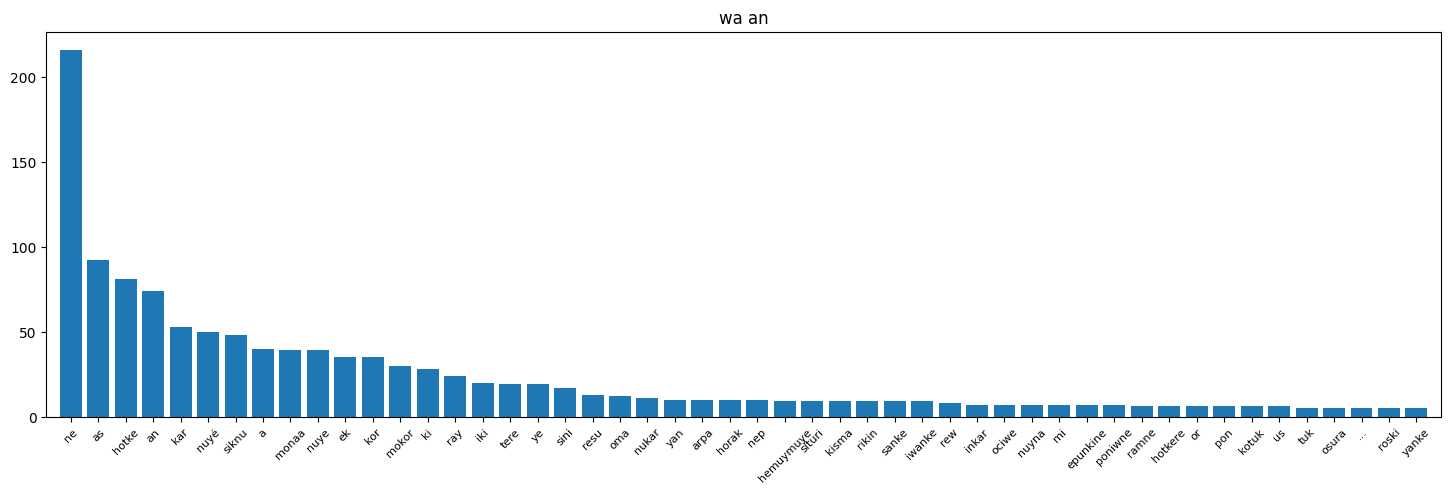

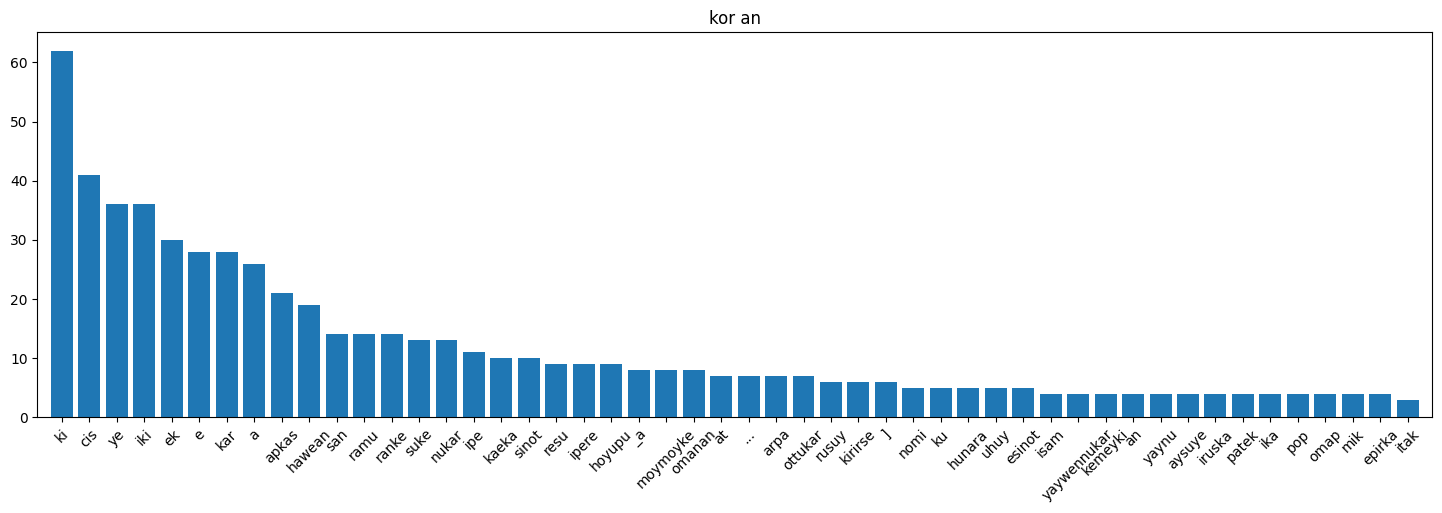

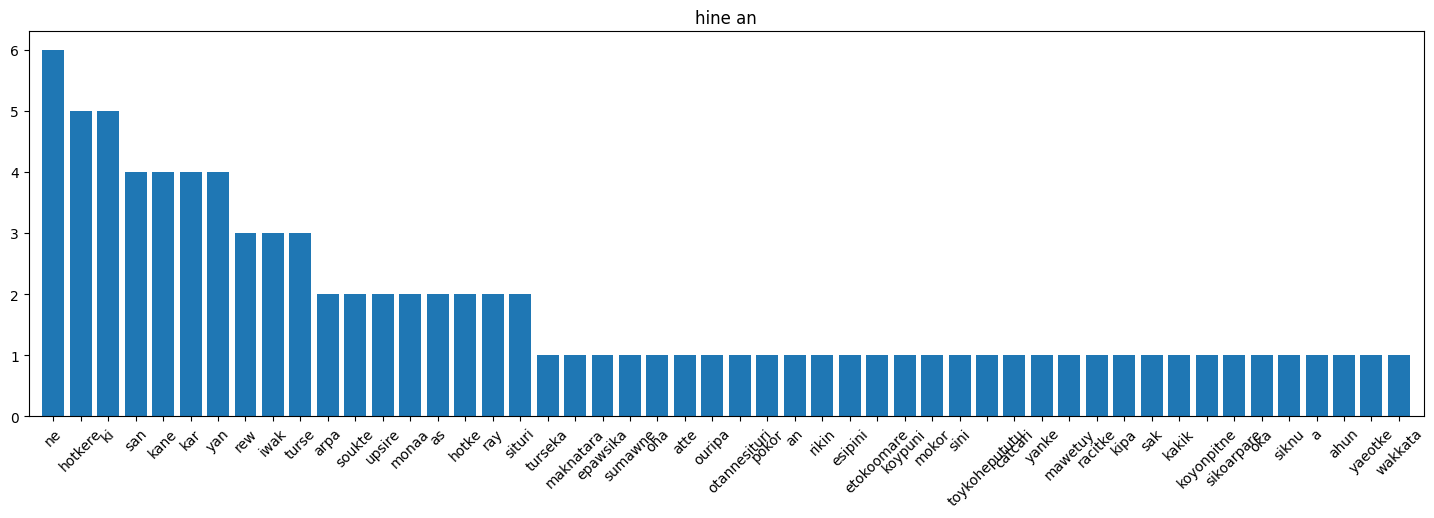

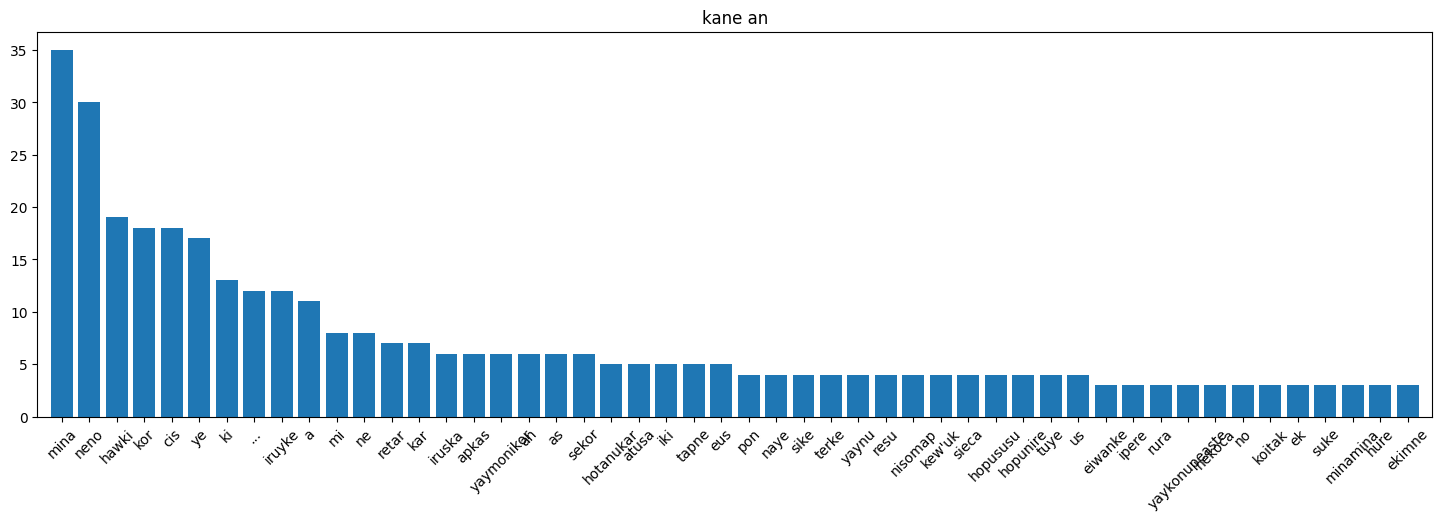

In [2]:
import pickle

with open("../output/annotated_translated_tokenized_corpus_by_book.pkl", "rb") as f:
    corpus = pickle.load(f)
# find all verb before of wa an (_a an)
wa_an = []

for book, texts in corpus.items():
    for text in texts:
        words = text["words"]
        for i, word in enumerate(words):
            if i < len(words) - 1 and word == "wa" and words[i + 1] == "an":
                if i > 0:
                    if words[i - 1] in ["=an", "=as"]:
                        wa_an.append(words[i - 2])
                    else:
                        wa_an.append(words[i - 1])


kor_an = []

for book, texts in corpus.items():
    for text in texts:
        words = text["words"]
        for i, word in enumerate(words):
            if i < len(words) - 1 and word == "kor" and words[i + 1] == "an":
                if i > 0:
                    if words[i - 1] in ["=an", "=as"]:
                        kor_an.append(words[i - 2])
                    else:
                        kor_an.append(words[i - 1])

hine_an = []

for book, texts in corpus.items():
    for text in texts:
        words = text["words"]
        for i, word in enumerate(words):
            if i < len(words) - 1 and word == "hine" and words[i + 1] == "an":
                if i > 0:
                    if words[i - 1] in ["=an", "=as"]:
                        hine_an.append(words[i - 2])
                    else:
                        hine_an.append(words[i - 1])

kane_an = []

for book, texts in corpus.items():
    for text in texts:
        words = text["words"]
        for i, word in enumerate(words):
            if i < len(words) - 1 and word == "kane" and words[i + 1] == "an":
                if i > 0:
                    if words[i - 1] in ["=an", "=as"]:
                        kane_an.append(words[i - 2])
                    else:
                        kane_an.append(words[i - 1])

from collections import Counter

import matplotlib.pyplot as plt

wa_an_counter = Counter(wa_an)
kor_an_counter = Counter(kor_an)
hine_an_counter = Counter(hine_an)
kane_an_counter = Counter(kane_an)

wa_an_counter.most_common(10)
kor_an_counter.most_common(10)
hine_an_counter.most_common(10)
kane_an_counter.most_common(10)

# draw plot

# wa_an_counter = dict(wa_an_counter)
# kor_an_counter = dict(kor_an_counter)

# remove margin

plt.tight_layout()

plt.figure(figsize=(18, 5))
plt.margins(x=0.01)
# plt.bar(wa_an_counter.keys(), wa_an_counter.values())
# most common 100
plt.bar(*zip(*wa_an_counter.most_common(50)))
plt.xticks(rotation=45, fontsize=8)
plt.savefig("output/wa_an.png", dpi=350, bbox_inches="tight")
plt.title("wa an")
# plt.subplots_adjust(bottom=0.5)

plt.figure(figsize=(18, 5))
plt.margins(x=0.01)
plt.bar(*zip(*kor_an_counter.most_common(50)))
plt.xticks(rotation=45)
plt.savefig("output/kor_an.png", dpi=350, bbox_inches="tight")
plt.title("kor an")

plt.figure(figsize=(18, 5))
plt.margins(x=0.01)
plt.bar(*zip(*hine_an_counter.most_common(50)))
plt.xticks(rotation=45)
plt.savefig("output/hine_an.png", dpi=350, bbox_inches="tight")
plt.title("hine an")

plt.figure(figsize=(18, 5))
plt.margins(x=0.01)
plt.bar(*zip(*kane_an_counter.most_common(50)))
plt.xticks(rotation=45)
plt.savefig("output/kane_an.png", dpi=350, bbox_inches="tight")
plt.title("kane an")
# plt.subplots_adjust(bottom=0.5)

# for book, texts in translation_pair_by_book.items():
#     for text in texts:
# break

#         print(f"{book}: {text['sentence']}")
#         print(words)
#         print(wa_an.append(text))

/home/mkpoli/projects/Ainu/ainu-corpora-process/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65341 (\N{FULLWIDTH RIGHT SQUARE BRACKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/mkpoli/projects/Ainu/ainu-corpora-process/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65364 (\N{FULLWIDTH LATIN SMALL LETTER T}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


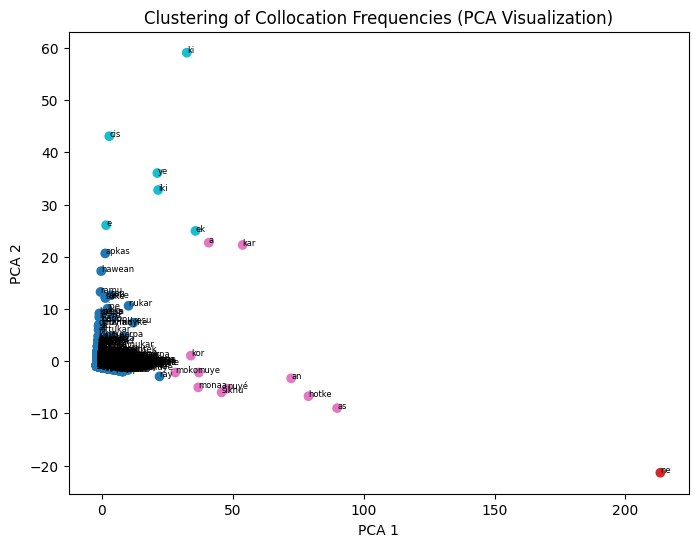

In [3]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1) Get the unique words from all counters
all_words = (
    set(wa_an_counter.keys())
    .union(kor_an_counter.keys())
    .union(hine_an_counter.keys())
    .union(kane_an_counter.keys())
)

# 2) Build frequency vectors for each word
rows = []
for w in all_words:
    rows.append(
        {
            "word": w,
            "wa_an_freq": wa_an_counter[w],
            "kor_an_freq": kor_an_counter[w],
            "hine_an_freq": hine_an_counter[w],
            "kane_an_freq": kane_an_counter[w],
        }
    )

df = pd.DataFrame(rows)

# 3) K-Means Clustering on frequency columns
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
df["cluster"] = kmeans.fit_predict(
    df[["wa_an_freq", "kor_an_freq", "hine_an_freq", "kane_an_freq"]]
)

# 4) Optional: PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(
    df[["wa_an_freq", "kor_an_freq", "hine_an_freq", "kane_an_freq"]]
)
df["pca1"] = reduced[:, 0]
df["pca2"] = reduced[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(df["pca1"], df["pca2"], c=df["cluster"], cmap="tab10")
for i, row in df.iterrows():
    # Optional: label each point with its word
    # Adjust offsets (e.g. 1, 1) to avoid overlapping text
    plt.text(row["pca1"], row["pca2"], row["word"], fontsize=6)

plt.title("Clustering of Collocation Frequencies (PCA Visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

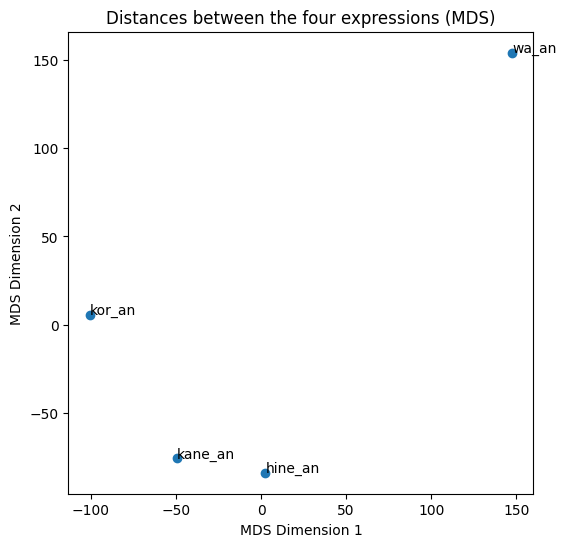

In [5]:
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# Assume we have 4 Counter objects already populated:
# wa_an_counter, kor_an_counter, hine_an_counter, kane_an_counter

# 1) Gather all unique words
all_words = (
    set(wa_an_counter.keys())
    | set(kor_an_counter.keys())
    | set(hine_an_counter.keys())
    | set(kane_an_counter.keys())
)
all_words = list(all_words)  # so we can index them

# 2) Build frequency vectors for each expression
counters = [wa_an_counter, kor_an_counter, hine_an_counter, kane_an_counter]
expressions = ["wa_an", "kor_an", "hine_an", "kane_an"]

vectors = []
for c in counters:
    # each vector is the count of all_words in a fixed order
    vectors.append([c[word] for word in all_words])

# 3) Compute pairwise distances
dist_matrix = pairwise_distances(vectors, metric="euclidean")
# or use `metric="cosine"` if you prefer cosine distance, etc.

# 4) (Optional) Visualize in 2D via MDS
mds = MDS(n_components=2, random_state=42, dissimilarity="precomputed")
coords = mds.fit_transform(dist_matrix)

plt.figure(figsize=(6, 6))
plt.scatter(coords[:, 0], coords[:, 1])

for i, label in enumerate(expressions):
    plt.annotate(label, (coords[i, 0], coords[i, 1]))

plt.title("Distances between the four expressions (MDS)")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.savefig("output/mds.png", dpi=350, bbox_inches="tight")
plt.show()

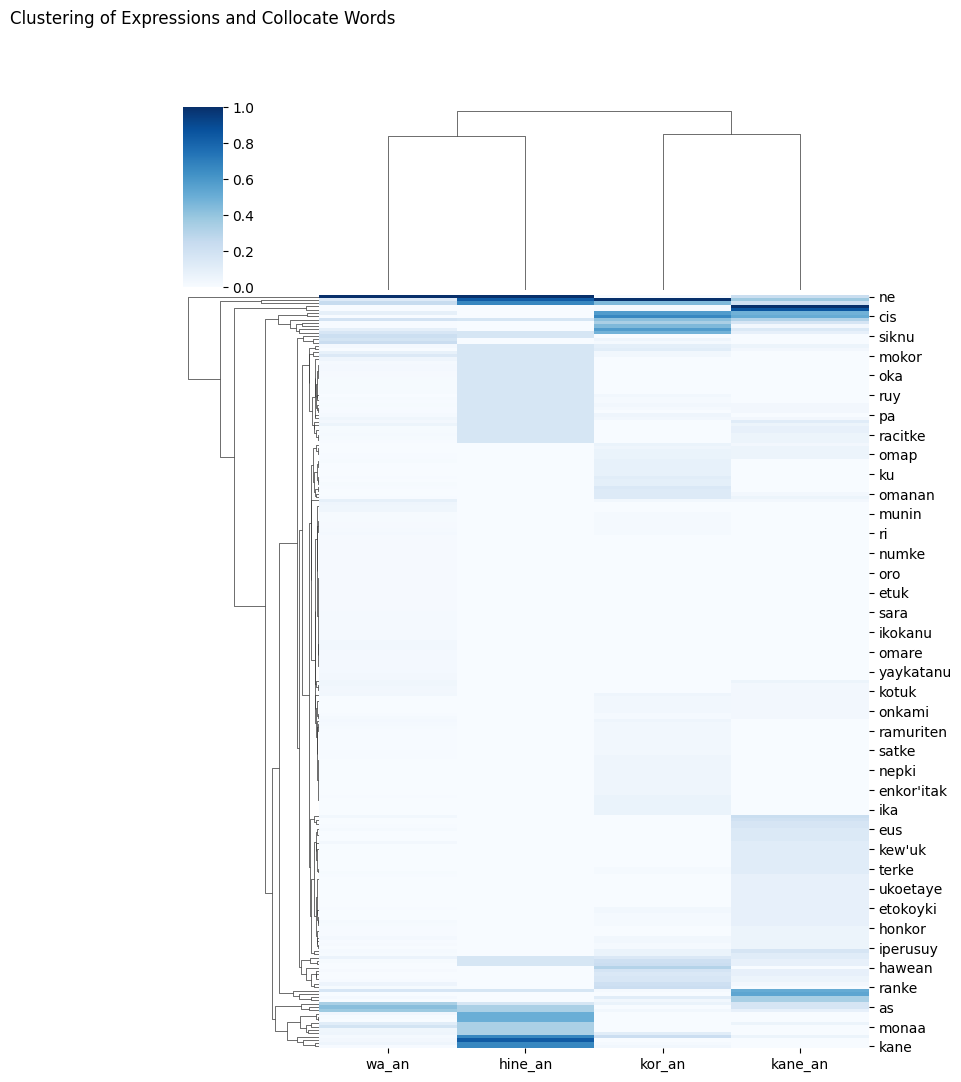

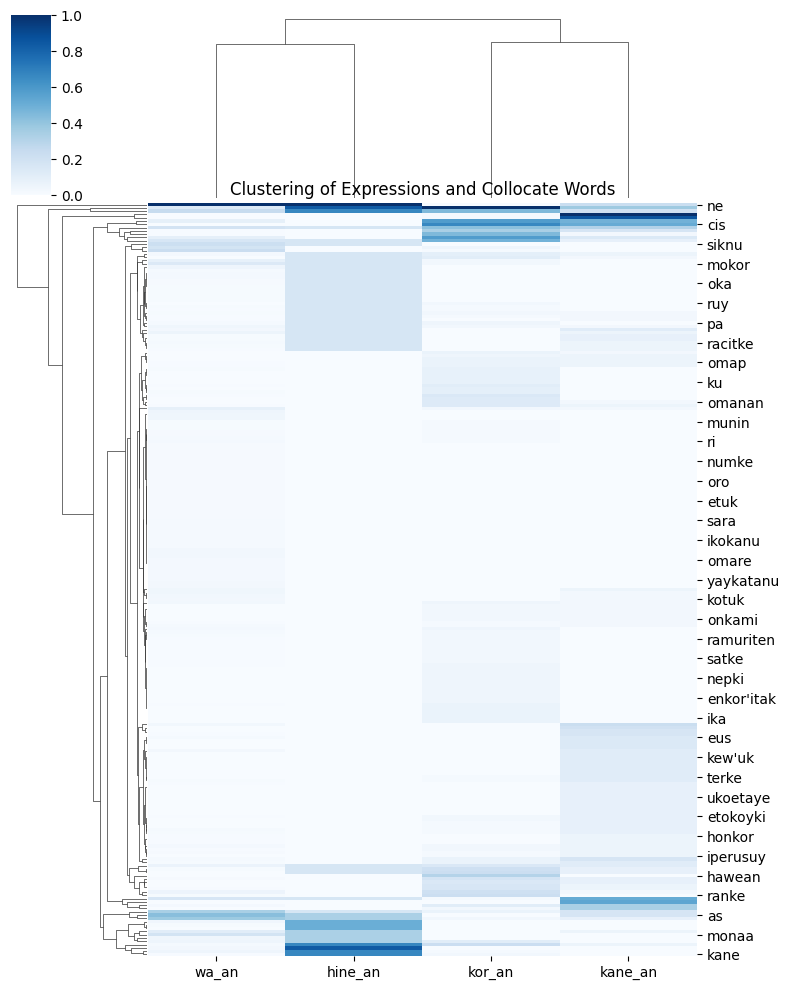

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Suppose you have these four Counters: wa_an_counter, kor_an_counter, hine_an_counter, kane_an_counter

# 1) Get the union of all unique words
all_words = (
    set(wa_an_counter.keys())
    | set(kor_an_counter.keys())
    | set(hine_an_counter.keys())
    | set(kane_an_counter.keys())
)
all_words = list(all_words)  # so we can iterate in a fixed order

# 2) Build a matrix with shape (number_of_words, 4)
#    Each row = one word
#    Each column = an expression’s frequency of that word
matrix = []
for w in all_words:
    matrix.append(
        [
            wa_an_counter[w],
            kor_an_counter[w],
            hine_an_counter[w],
            kane_an_counter[w],
        ]
    )

df = pd.DataFrame(
    matrix, columns=["wa_an", "kor_an", "hine_an", "kane_an"], index=all_words
)

# 3) Optionally filter out words that rarely appear (for a less cluttered heatmap)
#    For example, keep only words whose sum of frequencies ≥ some threshold
df["total"] = df.sum(axis=1)
df = df[df["total"] >= 3]  # pick a threshold that makes sense for your data
df.drop(columns=["total"], inplace=True)

# 4) Draw a cluster heatmap
sns.clustermap(
    df,
    method="average",  # link method for hierarchical clustering
    metric="euclidean",  # or "cosine", etc.
    cmap="Blues",  # color scheme
    standard_scale=1,  # normalize each row (optional)
    figsize=(8, 10),
)

plt.title("Clustering of Expressions and Collocate Words", pad=60)
# Seaborn clustermap draws its own figure, so we can't just do plt.show() after adding a title.
# Instead, you can do something like:
g = sns.clustermap(
    df,
    method="average",
    metric="euclidean",
    cmap="Blues",
    standard_scale=1,
    figsize=(8, 10),
)
g.ax_heatmap.set_title("Clustering of Expressions and Collocate Words")
plt.savefig("output/clustermap.png", dpi=350, bbox_inches="tight")
plt.show()
